In [5]:

# PROJETO APLICADO I - CURSO BANCO DE DADOS
# ANO 2026 - 1º SEMESTRE - TURMA 201825168.000.02A
# 1.IMPORTAÇÃO DE BIBLIOTECAS

import pandas as pd
import numpy as np


# importação do dataset
df = pd.read_csv('dataset_grupo2.csv')
df.head()


# Para Visualização dos gráficos o grupo importou essas bibliotecas
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configurações gerais de visualização dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'

# Impedir avisos desnecessários
import warnings
warnings.filterwarnings('ignore')

print("---------------------------------------------------")
print(' Bibliotecas importadas com sucesso!')
print("---------------------------------------------------")

---------------------------------------------------
 Bibliotecas importadas com sucesso!
---------------------------------------------------


In [6]:
# 2. TRADUÇÃO DOS CABEÇALHOS PARA PORTUGUÊS
# Dicionário de tradução das colunas

colunas_pt = {
    'sale_id'                 : 'codigo_venda',
    'sale_date'               : 'data_venda',
    'year'                    : 'ano',
    'quarter'                 : 'trimestre',
    'month'                   : 'mes',
    'country'                 : 'pais',
    'region'                  : 'regiao',
    'city'                    : 'cidade',
    'product_name'            : 'produto',
    'category'                : 'categoria',
    'storage'                 : 'armazenamento',
    'color'                   : 'cor',
    'unit_price_usd'          : 'preco_usd',
    'discount_pct'            : 'desconto_pct',
    'units_sold'              : 'unidades_vendidas',
    'discounted_price_usd'    : 'preco_com_desconto_usd',
    'revenue_usd'             : 'receita_usd',
    'currency'                : 'moeda',
    'fx_rate_to_usd'          : 'taxa_cambio',
    'revenue_local_currency'  : 'receita_moeda_local',
    'sales_channel'           : 'canal_venda',
    'payment_method'          : 'metodo_pagamento',
    'customer_segment'        : 'segmento_cliente',
    'customer_age_group'      : 'faixa_etaria',
    'previous_device_os'      : 'aparelho_anterior',
    'customer_rating'         : 'nota_cliente',
    'return_status'           : 'status_retorno'
}

df.rename(columns=colunas_pt, inplace=True)
print("---------------------------------------------------")
print('Colunas renomeadas para português:')
print("---------------------------------------------------")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

---------------------------------------------------
Colunas renomeadas para português:
---------------------------------------------------
1. codigo_venda;data_venda;ano;quartil;mes;pais;regiao;cidade;nome_produto;categoria;armazenamento;cor;preco;desconto;unidades_venda;preco_com_desconto;receita;moeda;taxa_usd;faturamento_moeda_local;canal_venda;metodo_pagamento;seguimento_cliente;faixa_etaria_cliente;aparelho_anterior;nota_cliente;status_retorno


In [61]:
# 3. TRATAMENTO DOS DADOS - TIPOS DE DADOS
# Converter data_venda para tipo datetime

# Verificar se a primeira linha de dados contém valores de cabeçalho duplicados
# Isso é indicado pela string 'sale_date' na coluna 'data_venda'
if not df.empty and df.iloc[0]['data_venda'] == 'sale_date':
    print("Identificado e removendo linha extra que contém cabeçalhos repetidos.")
    df = df.iloc[1:].copy()
    df.reset_index(drop=True, inplace=True)

df['data_venda'] = pd.to_datetime(df['data_venda'], dayfirst=True)

# Confirmar conversão dos dados
print("---------------------------------------------------")
print(f'Tipo da coluna data_venda: {df["data_venda"].dtype}')
print(f'Período do dataset: {df["data_venda"].min().date()} até {df["data_venda"].max().date()}')
print("---------------------------------------------------")

Identificado e removendo linha extra que contém cabeçalhos repetidos.
---------------------------------------------------
Tipo da coluna data_venda: datetime64[ns]
Período do dataset: 2022-01-01 até 2024-12-31
---------------------------------------------------


In [7]:
# 4. TRATAMENTO DOS DADOS - VALORES AUSENTES
# Contagem e percentual de nulos por coluna
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)

resumo_nulos = pd.DataFrame({
    'Qtd. Nulos'    : nulos,
    'Percentual (%)': pct_nulos
}).query('`Qtd. Nulos` > 0').sort_values('Qtd. Nulos', ascending=False)

print("---------------------------------------------------")
print('Colunas com valores ausentes:')
display(resumo_nulos)
print("---------------------------------------------------")

---------------------------------------------------
Colunas com valores ausentes:


,Qtd. Nulos,Percentual (%)


---------------------------------------------------


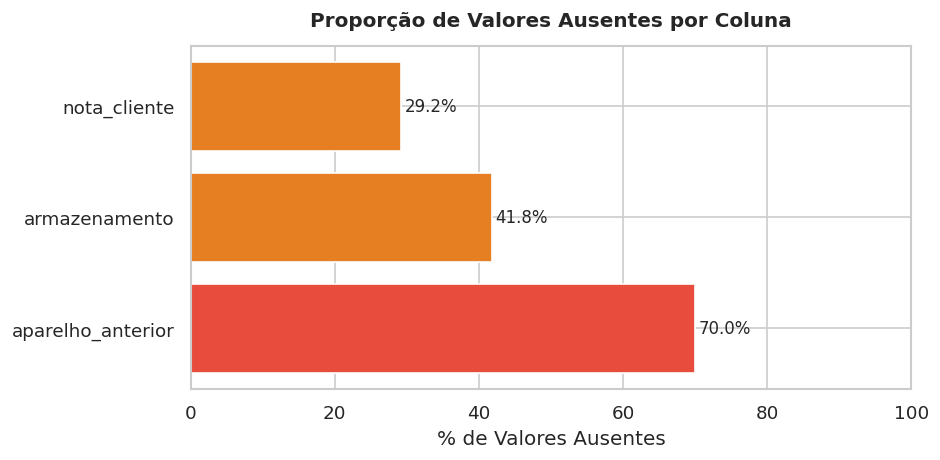

In [63]:
# TRATAMENTO DOS DADOS - VALORES AUSENTES → VISUALIZAÇÃO
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(
    resumo_nulos.index,
    resumo_nulos['Percentual (%)'],
    color=['#e74c3c' if v > 50 else '#e67e22' if v > 20 else '#f1c40f' for v in resumo_nulos['Percentual (%)']]
)

# Rótulos nas barras
for bar, val in zip(bars, resumo_nulos['Percentual (%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_xlabel('% de Valores Ausentes')
ax.set_title('Proporção de Valores Ausentes por Coluna', fontweight='bold', pad=12)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

In [64]:
# VALORES AUSENTES → TRATAMENTO

# 'armazenamento': ~42% nulo → faz sentido para categorias sem variação de storage, comoo airpods, accessories e apple watch. Colocamos 'N/A'

df['armazenamento'].fillna('N/A', inplace=True);

# 'aparelho_anterior': ~70% nulo → coluna com poucos dados válidos. Colocamos 'Desconhecido' para manter a linha na nossa base.
df['aparelho_anterior'].fillna('Desconhecido', inplace=True);

# 'nota_cliente': ~29% nulo → valores numéricos. Colocamos a mediana nos casos ausentes
# Converter a coluna para numérico primeiro, forçando erros para NaN
df['nota_cliente'] = pd.to_numeric(df['nota_cliente'], errors='coerce');
mediana_nota = df['nota_cliente'].median();
df['nota_cliente'].fillna(mediana_nota, inplace=True);

# Converter outras colunas numéricas para o tipo apropriado
numeric_cols_to_convert = ['preco', 'desconto', 'unidades_venda', 'preco_com_desconto', 'receita', 'taxa_usd', 'faturamento_moeda_local'];
for col in numeric_cols_to_convert:
    # Verifica se a coluna existe no DataFrame para evitar KeyError em caso de inconsistência de nomes
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce');

print("---------------------------------------------------")
print('\n Verificação pós-tratamento:');
print(df.isnull().sum()[df.isnull().sum() > 0]);
print('   → Nenhum valor ausente restante.' if df.isnull().sum().sum() == 0 else '');
print("---------------------------------------------------")

---------------------------------------------------

 Verificação pós-tratamento:
Series([], dtype: int64)
   → Nenhum valor ausente restante.
---------------------------------------------------


In [65]:
# 5. ANÁLISE ESTATÍSTICA
# Aplicamos estatística descritiva de colunas numéricas

df[['preco', 'desconto', 'unidades_venda',
    'receita', 'nota_cliente']].describe().round(2)

,preco,desconto,unidades_venda,receita,nota_cliente
count,11500.00,11500.00,11500.00,11500.00,11500.00
mean,807.85,3.84,2.02,1568.32,4.00
std,1112.44,4.78,1.44,2839.76,0.48
min,26.69,0.00,1.00,23.00,3.00
25%,180.15,0.00,1.00,305.74,3.70
50%,593.90,2.00,1.00,833.04,4.00
75%,958.39,7.00,3.00,1748.36,4.30
max,7551.01,15.00,8.00,59529.52,5.00


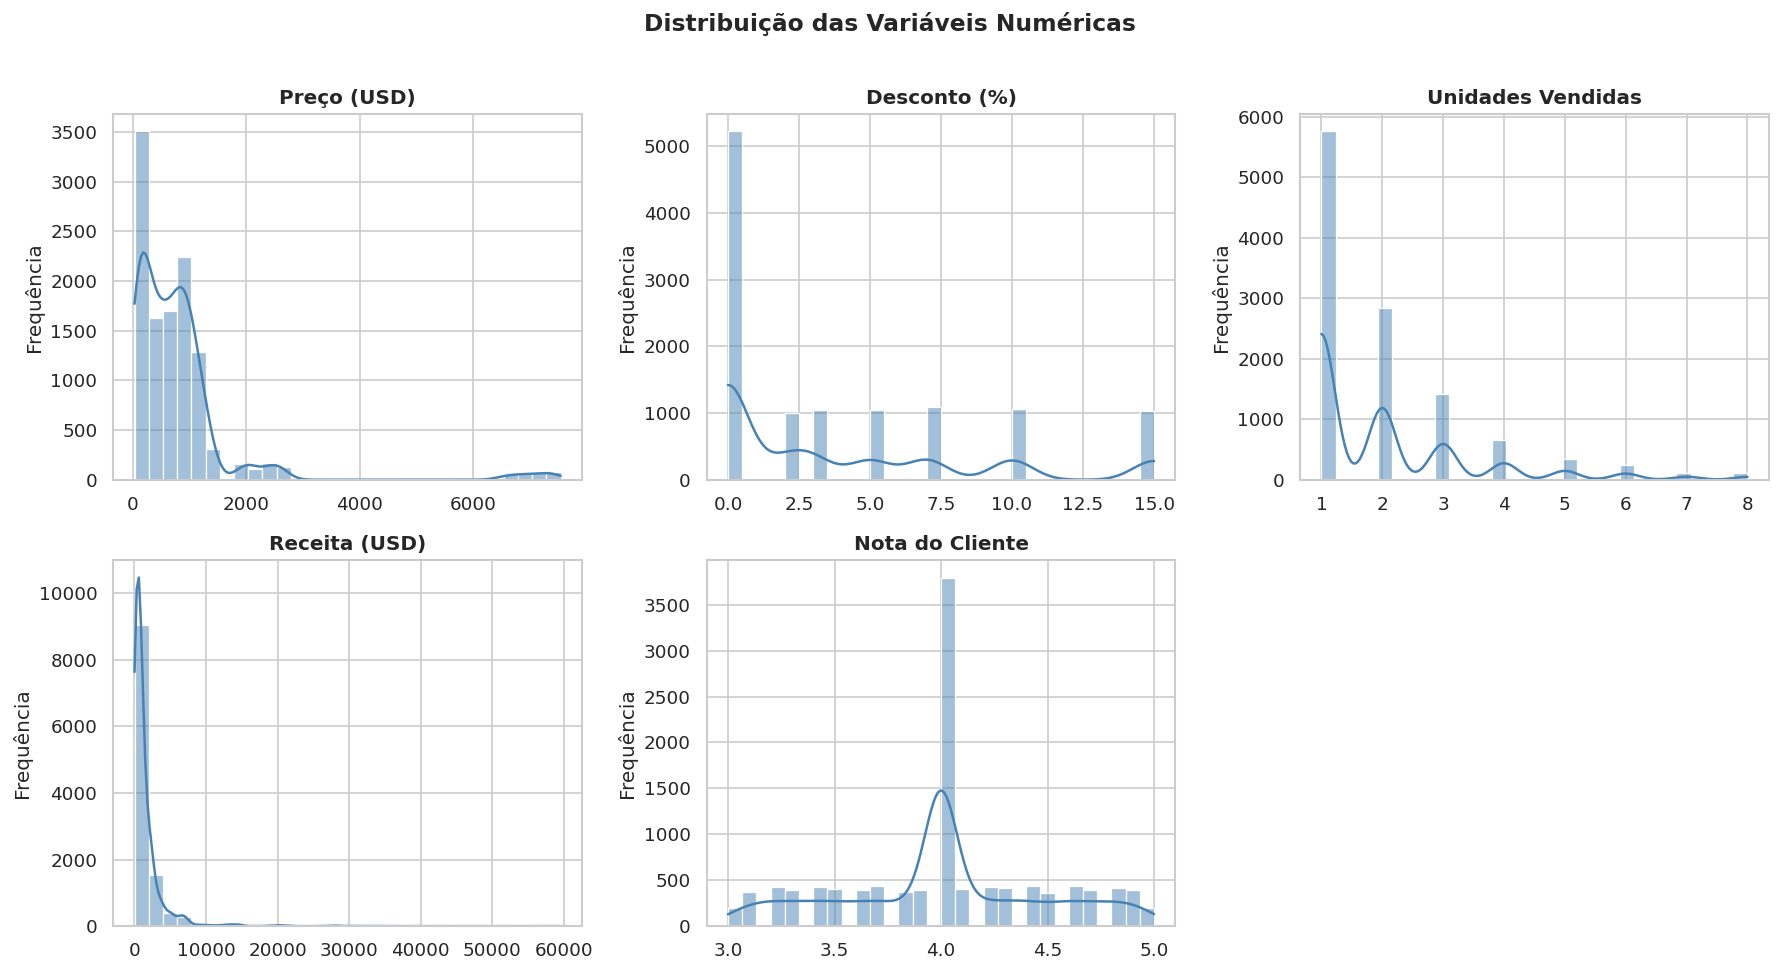

In [66]:
# DISTRIBUIÇÃO DAS VARIÁVEIS NUMÉRICAS PRINCIPAIS

variaveis = ['preco', 'desconto', 'unidades_venda', 'receita', 'nota_cliente']
titulos   = ['Preço (USD)', 'Desconto (%)', 'Unidades Vendidas', 'Receita (USD)', 'Nota do Cliente']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, titulo) in enumerate(zip(variaveis, titulos)):
    sns.histplot(df[col], ax=axes[i], kde=True, color='steelblue', bins=30)
    axes[i].set_title(titulo, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequência')

# Ocultar o subplot extra
axes[-1].set_visible(False)

fig.suptitle('Distribuição das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

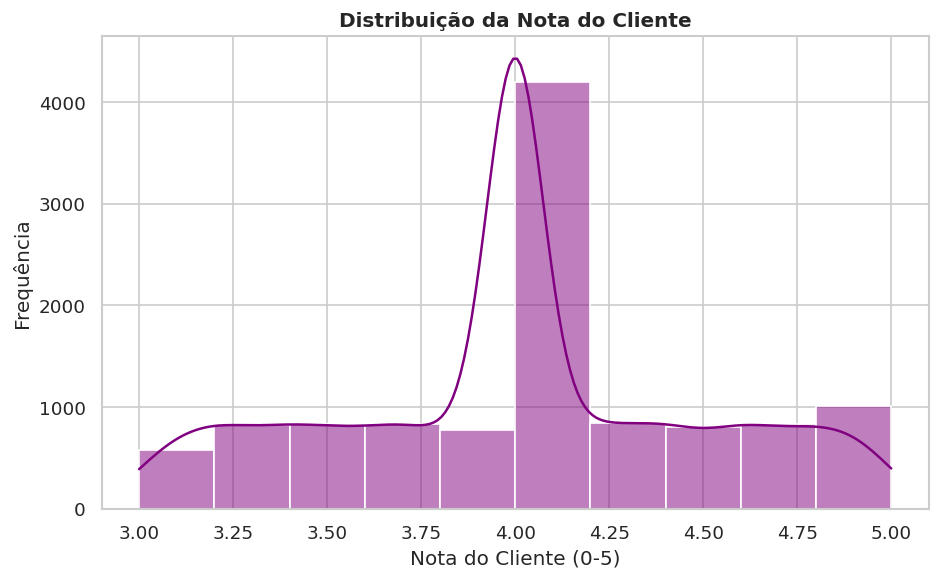

In [67]:
# DISTRIBUIÇÃO DA NOTA DO CLIENTE
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['nota_cliente'], ax=ax, kde=True, color='purple', bins=10)
ax.set_title('Distribuição da Nota do Cliente', fontweight='bold')
ax.set_xlabel('Nota do Cliente (0-5)')
ax.set_ylabel('Frequência')
plt.tight_layout()
plt.show()

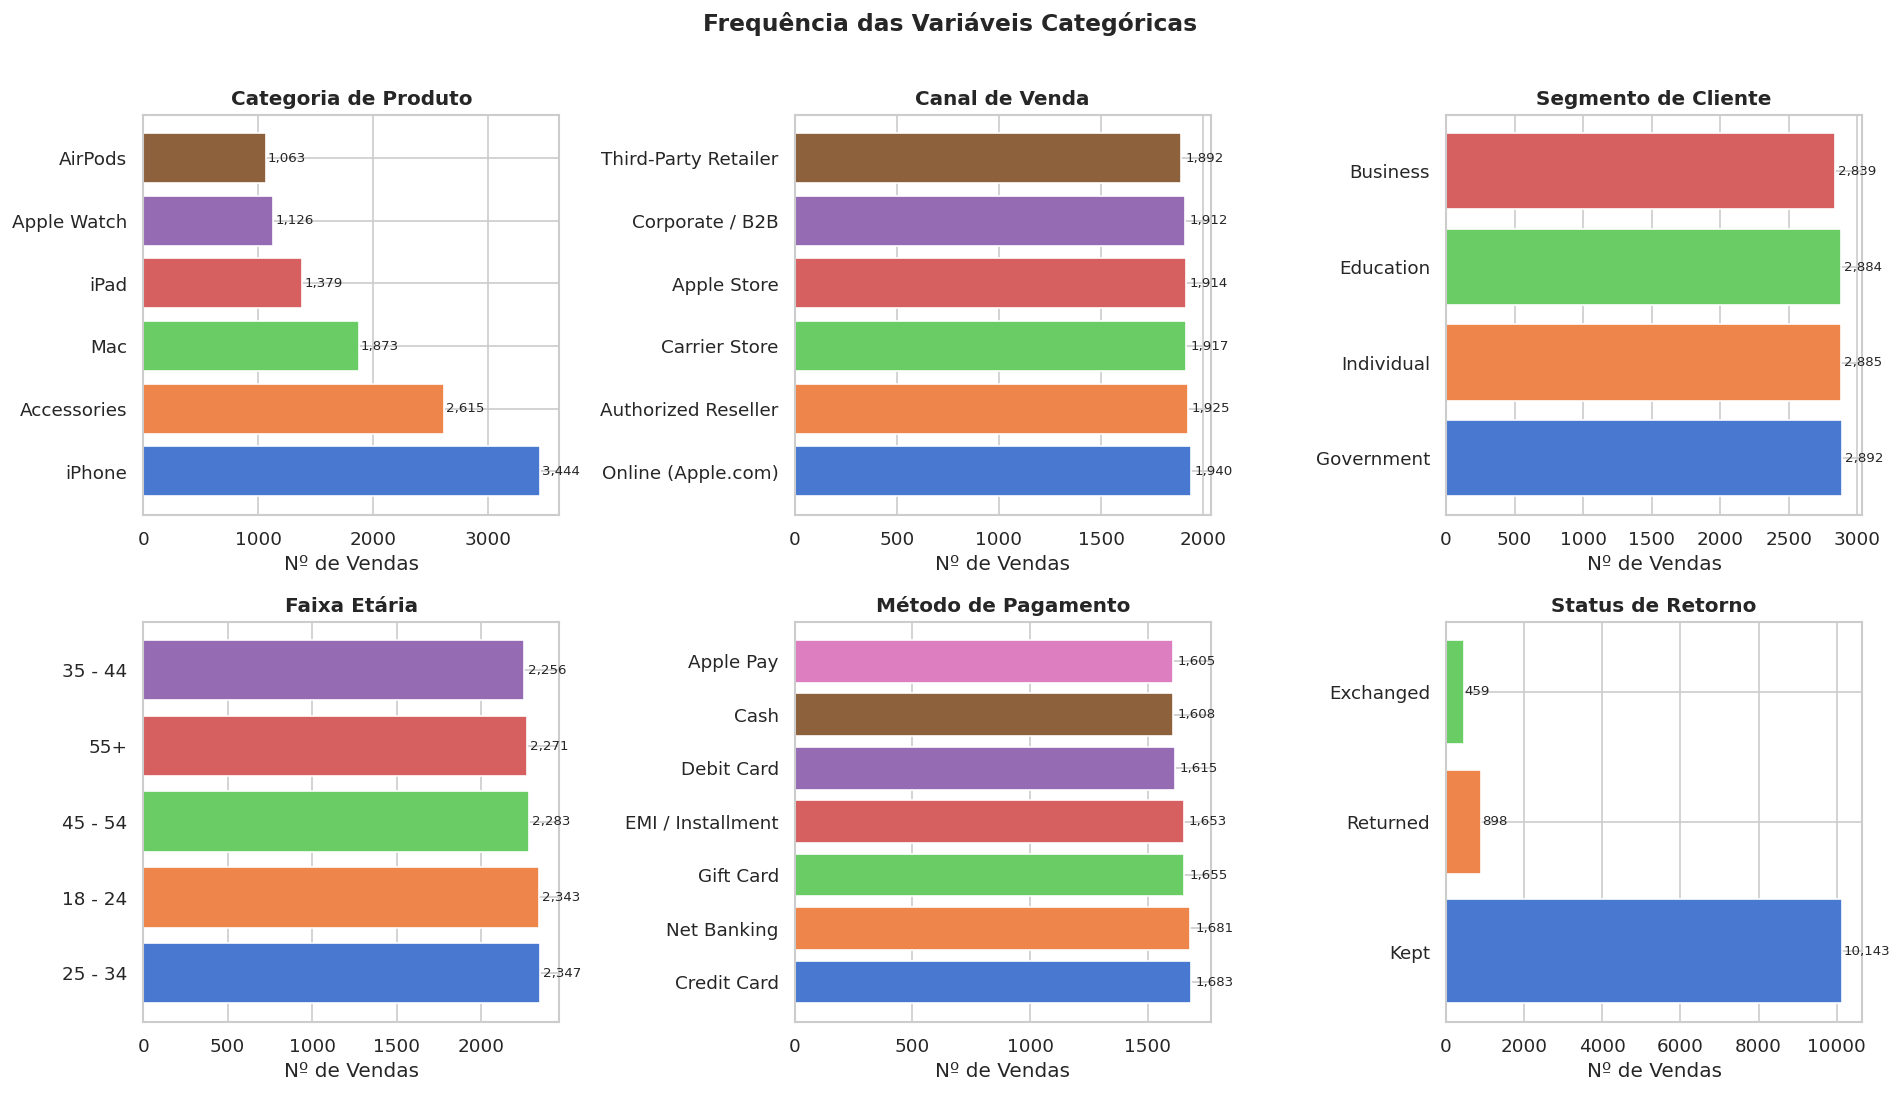

In [68]:
# ANÁLISE DAS VARIÁVEIS CATEGÓRICAS
# Frequência das principais variáveis categóricas
categoricas = {
    'categoria'        : 'Categoria de Produto',
    'canal_venda'      : 'Canal de Venda',
    'seguimento_cliente' : 'Segmento de Cliente',
    'faixa_etaria_cliente' : 'Faixa Etária',     # Corrected column name
    'metodo_pagamento' : 'Método de Pagamento',
    'status_retorno'   : 'Status de Retorno'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

paleta = sns.color_palette('muted')

for i, (col, titulo) in enumerate(categoricas.items()):
    contagem = df[col].value_counts()
    bars = axes[i].barh(contagem.index, contagem.values,
                        color=paleta[:len(contagem)])
    axes[i].set_title(titulo, fontweight='bold')
    axes[i].set_xlabel('Nº de Vendas')
    # Rótulos
    for bar, val in zip(bars, contagem.values):
        axes[i].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                     f'{val:,}', va='center', fontsize=8)

fig.suptitle('Frequência das Variáveis Categóricas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

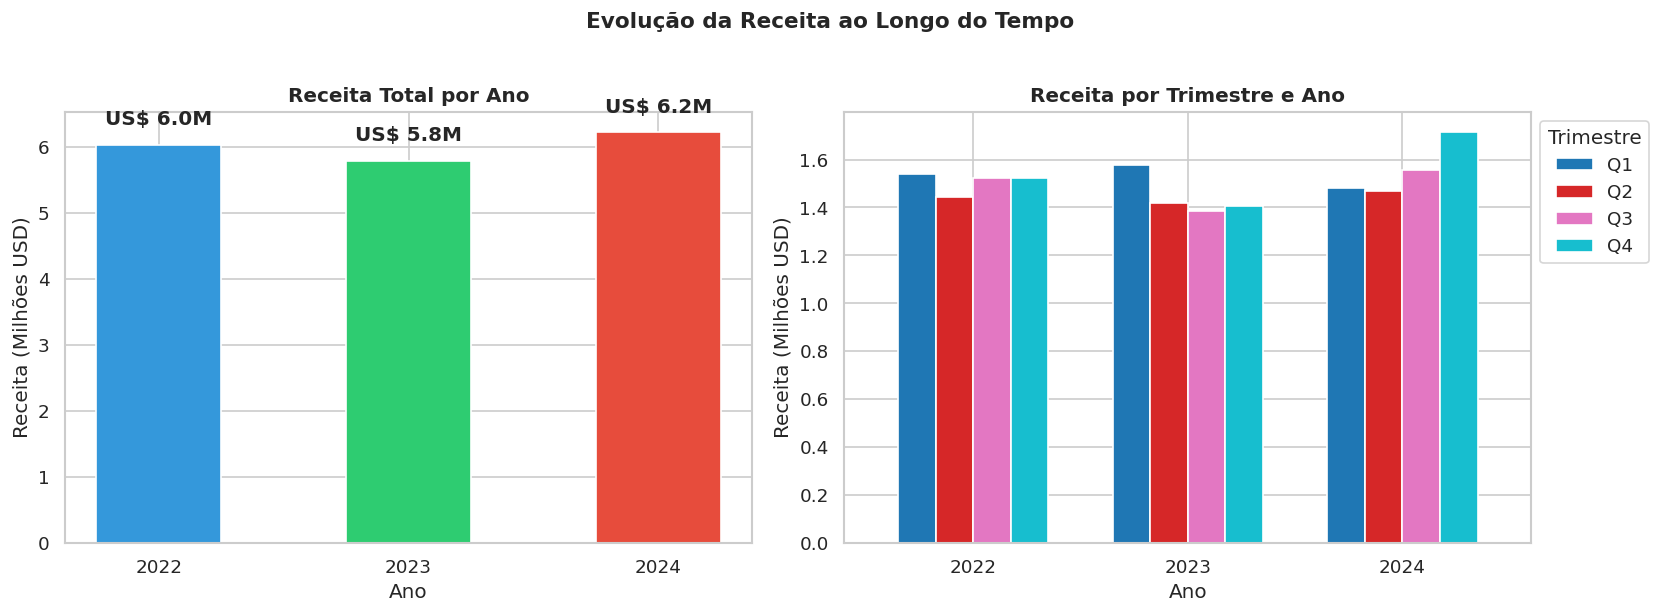

In [69]:
# 6. ANÁLISE TEMPORAL — RECEITA POR ANO E TRIMESTRE
# Receita total por ano
receita_ano = df.groupby('ano')['receita'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Receita por Ano ---
cores = ['#3498db', '#2ecc71', '#e74c3c']
bars = axes[0].bar(receita_ano['ano'].astype(str), receita_ano['receita'] / 1e6,
                   color=cores, width=0.5)
for bar, val in zip(bars, receita_ano['receita']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'US$ {val/1e6:.1f}M', ha='center', fontweight='bold')
axes[0].set_title('Receita Total por Ano', fontweight='bold')
axes[0].set_ylabel('Receita (Milhões USD)')
axes[0].set_xlabel('Ano')

# --- Gráfico 2: Receita por Trimestre (agrupado por ano) ---
pivot = df.groupby(['ano', 'quartil'])['receita'].sum().unstack('quartil') / 1e6
pivot.plot(kind='bar', ax=axes[1], colormap='tab10', width=0.7)
axes[1].set_title('Receita por Trimestre e Ano', fontweight='bold')
axes[1].set_ylabel('Receita (Milhões USD)')
axes[1].set_xlabel('Ano')
axes[1].legend(title='Trimestre', bbox_to_anchor=(1, 1))
axes[1].set_xticklabels(pivot.index.astype(str), rotation=0)

plt.suptitle('Evolução da Receita ao Longo do Tempo', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

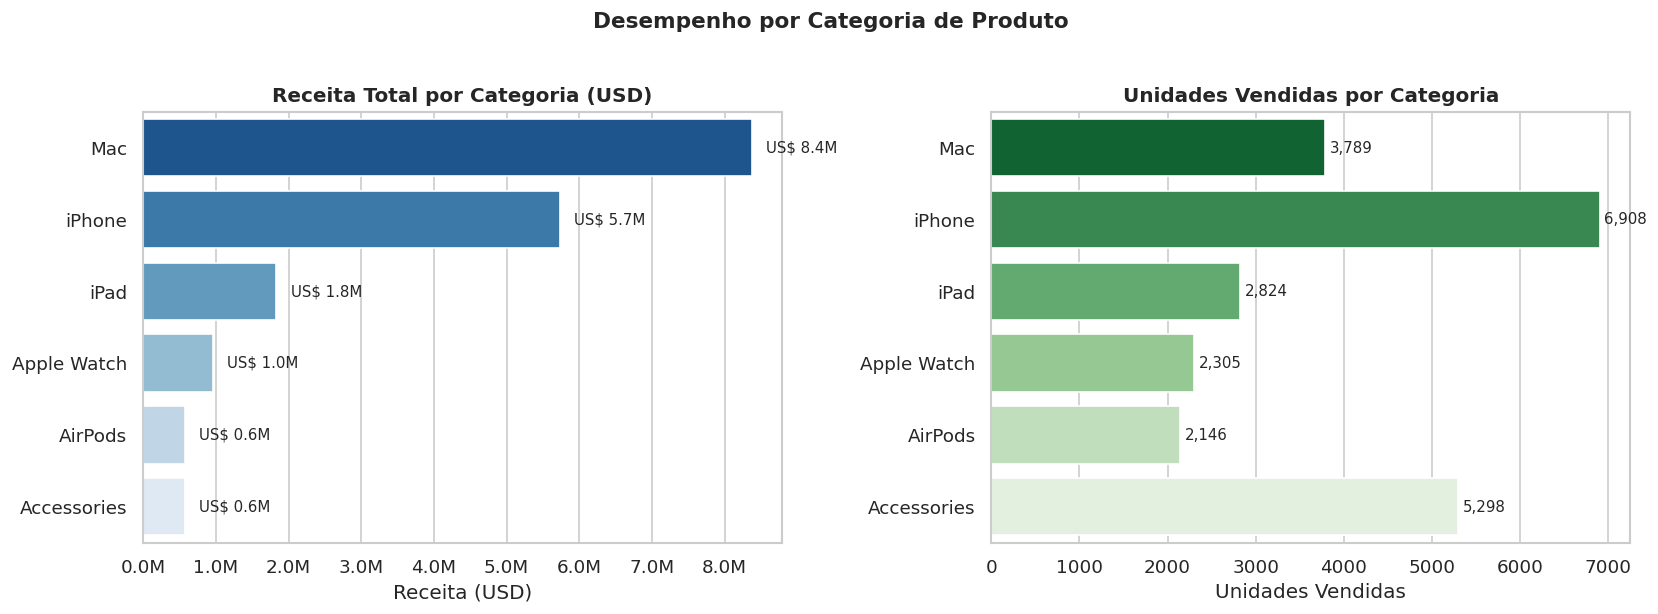

---------------------------------------------------

 Resumo por Categoria:
---------------------------------------------------


,Categoria,Receita Total,Unidades Vendidas,Ticket Médio
0,Mac,"US$ 8,369,961",3789,"US$ 4,469"
1,iPhone,"US$ 5,734,154",6908,"US$ 1,665"
2,iPad,"US$ 1,829,816",2824,"US$ 1,327"
3,Apple Watch,"US$ 958,774",2305,US$ 851
4,AirPods,"US$ 572,774",2146,US$ 539
5,Accessories,"US$ 570,190",5298,US$ 218


In [70]:
# 7. ANÁLISE DE PRODUTOS — RECEITA E VOLUME POR CATEGORIA
# Receita e unidades vendidas por categoria
resumo_cat = df.groupby('categoria').agg(
    receita_total   = ('receita', 'sum'),
    unidades_total  = ('unidades_venda', 'sum'),
    ticket_medio    = ('receita', 'mean')
).sort_values('receita_total', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Receita por categoria
sns.barplot(data=resumo_cat, x='receita_total', y='categoria',
            palette='Blues_r', ax=axes[0])
axes[0].set_title('Receita Total por Categoria (USD)', fontweight='bold')
axes[0].set_xlabel('Receita (USD)')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, val in enumerate(resumo_cat['receita_total']):
    axes[0].text(val + 2e5, i, f'US$ {val/1e6:.1f}M', va='center', fontsize=9)

# Unidades vendidas por categoria
sns.barplot(data=resumo_cat, x='unidades_total', y='categoria',
            palette='Greens_r', ax=axes[1])
axes[1].set_title('Unidades Vendidas por Categoria', fontweight='bold')
axes[1].set_xlabel('Unidades Vendidas')
axes[1].set_ylabel('')
for i, val in enumerate(resumo_cat['unidades_total']):
    axes[1].text(val + 50, i, f'{val:,}', va='center', fontsize=9)

plt.suptitle('Desempenho por Categoria de Produto', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("---------------------------------------------------")
print('\n Resumo por Categoria:')
print("---------------------------------------------------")
resumo_cat['receita_total'] = resumo_cat['receita_total'].map('US$ {:,.0f}'.format)
resumo_cat['ticket_medio']  = resumo_cat['ticket_medio'].map('US$ {:,.0f}'.format)
display(resumo_cat.rename(columns={
    'categoria'     : 'Categoria',
    'receita_total' : 'Receita Total',
    'unidades_total': 'Unidades Vendidas',
    'ticket_medio'  : 'Ticket Médio'
}))

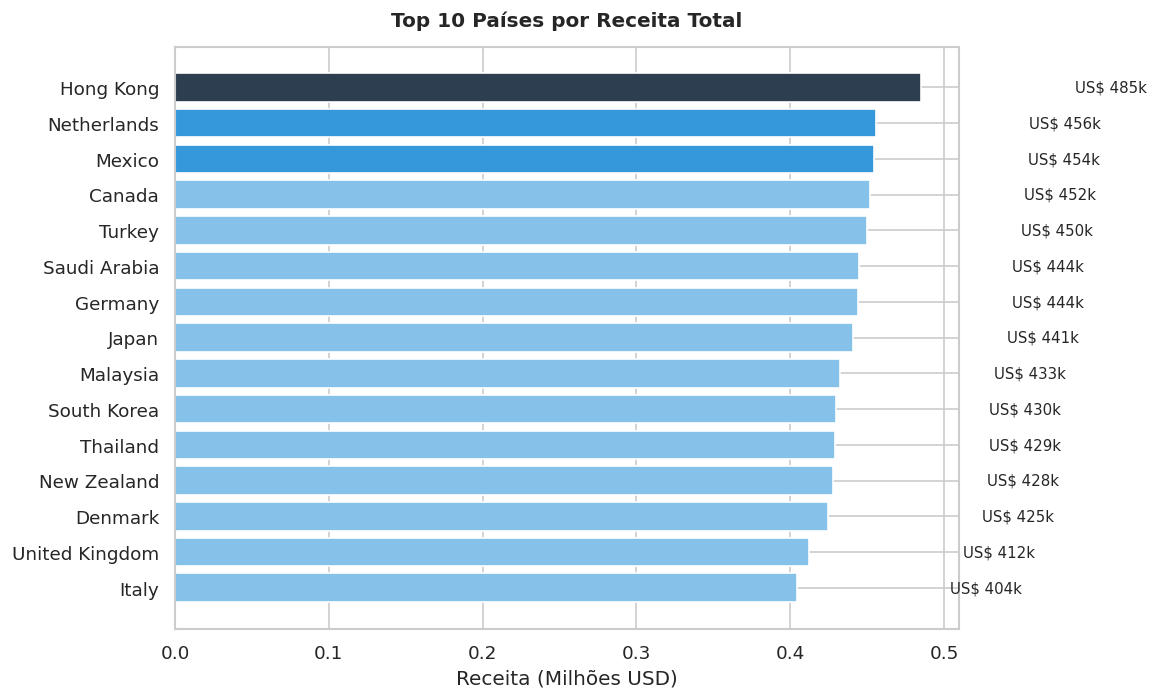

In [71]:
# 8. ANÁLISE GEOGRÁFICA — TOP 10 PAÍSES POR RECEITA
# Ranking dos 10 países com maior receita

top_paises = (df.groupby('pais')['receita']
                .sum()
                .sort_values(ascending=False)
                .head(15)
                .reset_index())

fig, ax = plt.subplots(figsize=(10, 6))

cores_paises = ['#2c3e50' if i == 0 else '#3498db' if i < 3 else '#85c1e9'
                for i in range(len(top_paises))]

bars = ax.barh(top_paises['pais'][::-1], top_paises['receita'][::-1] / 1e6,
               color=cores_paises[::-1])

for bar, val in zip(bars, top_paises['receita'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'US$ {val/1e3:.0f}k', va='center', fontsize=9)

ax.set_xlabel('Receita (Milhões USD)')
ax.set_title('Top 10 Países por Receita Total', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

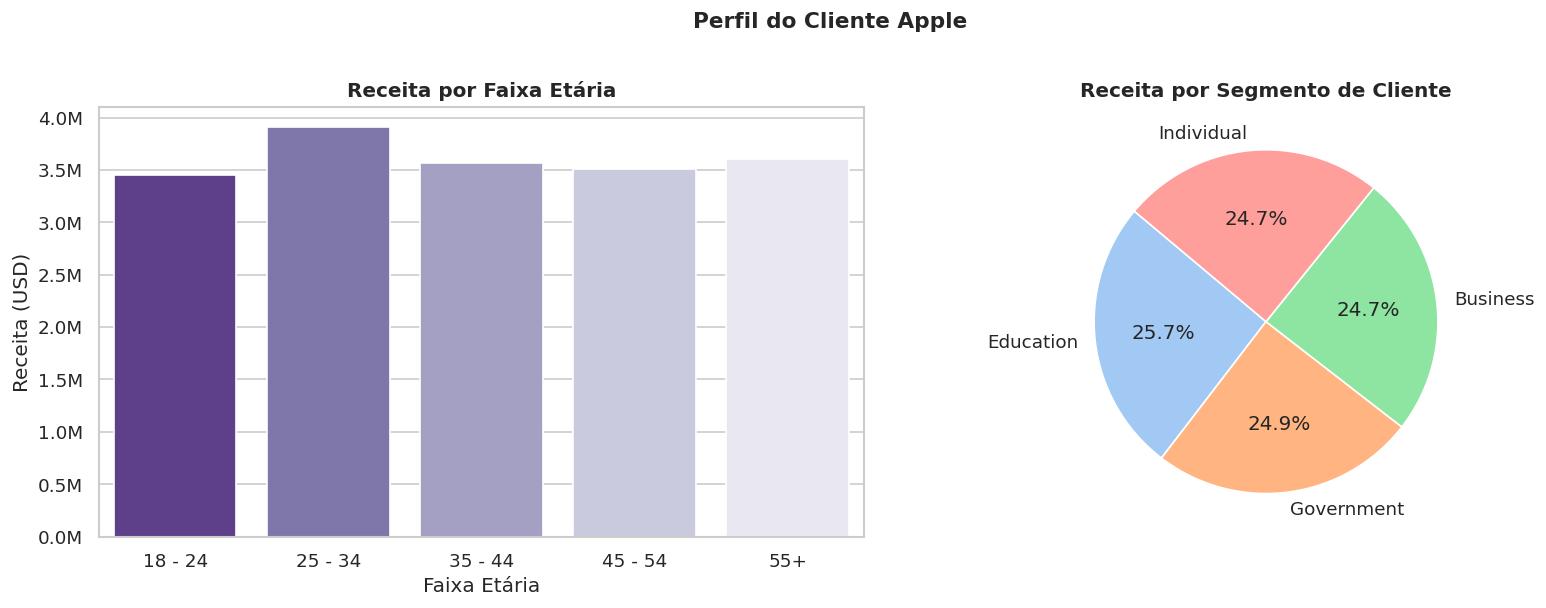

In [72]:

# 9. ANÁLISE DO PERFIL DO CLIENTE
# Receita por faixa etária e segmento de cliente

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Faixa Etária ---
faixa_receita = (df.groupby('faixa_etaria_cliente')['receita']
                   .sum()
                   .sort_index()
                   .reset_index())

sns.barplot(data=faixa_receita, x='faixa_etaria_cliente', y='receita',
            palette='Purples_r', ax=axes[0])
axes[0].set_title('Receita por Faixa Etária', fontweight='bold')
axes[0].set_xlabel('Faixa Etária')
axes[0].set_ylabel('Receita (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# --- Segmento de Cliente ---
seg_receita = (df.groupby('seguimento_cliente')['receita']
                 .sum()
                 .sort_values(ascending=False)
                 .reset_index())

wedges, texts, autotexts = axes[1].pie(
    seg_receita['receita'],
    labels=seg_receita['seguimento_cliente'],
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=140
)
axes[1].set_title('Receita por Segmento de Cliente', fontweight='bold')

plt.suptitle('Perfil do Cliente Apple', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

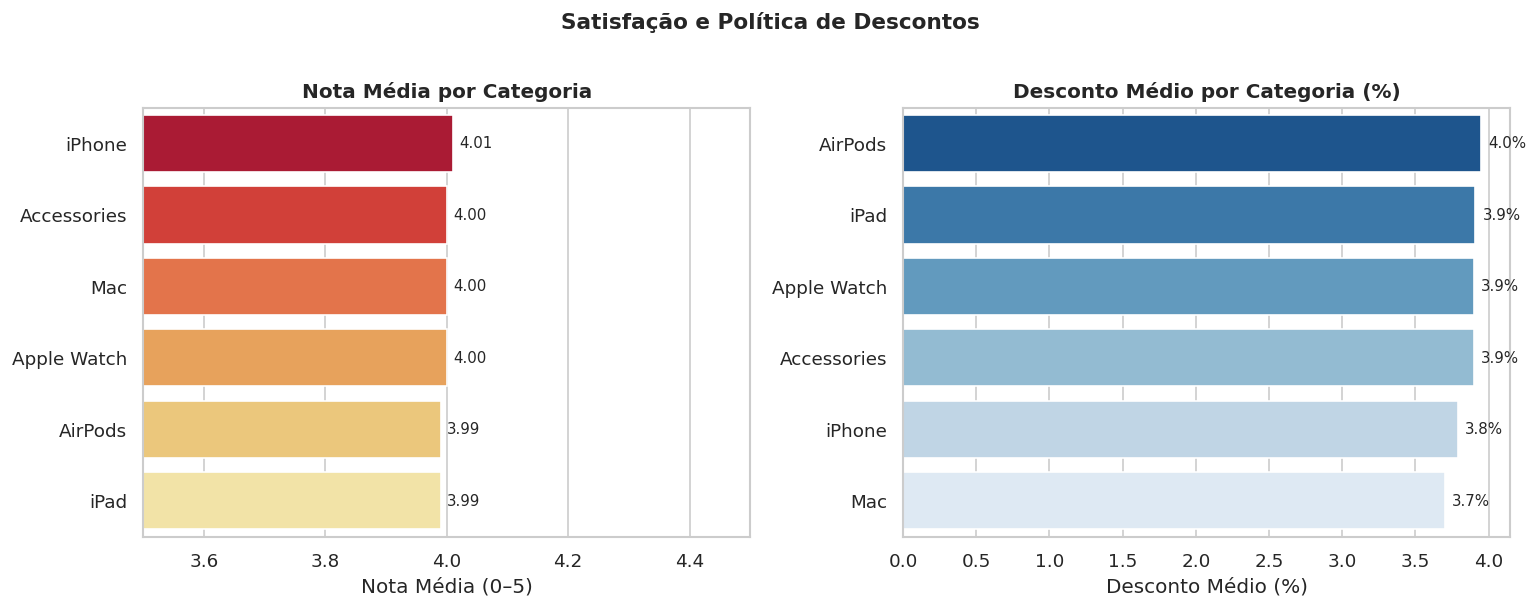

In [73]:
# 10. ANÁLISE DE DESCONTO E SATISFAÇÃO
# Desconto médio e nota média por categoria

resumo_satisf = df.groupby('categoria').agg(
    desconto_medio = ('desconto', 'mean'),
    nota_media     = ('nota_cliente', 'mean')
).round(2).sort_values('nota_media', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Nota média por categoria
sns.barplot(data=resumo_satisf, x='nota_media', y='categoria',
            palette='YlOrRd_r', ax=axes[0])
axes[0].set_xlim(3.5, 4.5)
axes[0].set_title('Nota Média por Categoria', fontweight='bold')
axes[0].set_xlabel('Nota Média (0–5)')
axes[0].set_ylabel('')
for i, val in enumerate(resumo_satisf['nota_media']):
    axes[0].text(val + 0.01, i, f'{val:.2f}', va='center', fontsize=9)

# Desconto médio por categoria
sns.barplot(data=resumo_satisf.sort_values('desconto_medio', ascending=False),
            x='desconto_medio', y='categoria', palette='Blues_r', ax=axes[1])
axes[1].set_title('Desconto Médio por Categoria (%)', fontweight='bold')
axes[1].set_xlabel('Desconto Médio (%)')
axes[1].set_ylabel('')
for i, val in enumerate(resumo_satisf.sort_values('desconto_medio', ascending=False)['desconto_medio']):
    axes[1].text(val + 0.05, i, f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Satisfação e Política de Descontos', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

-- Distribuição de Status de Retorno:
         Kept: 88.2%
     Returned: 7.8%
    Exchanged: 4.0%


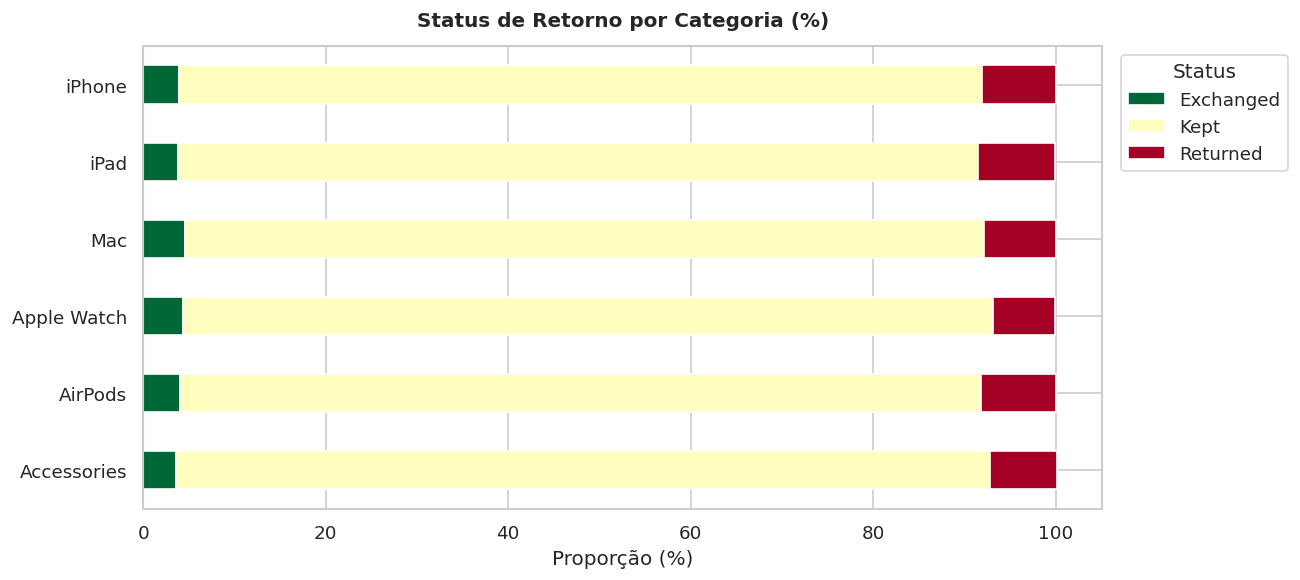

In [76]:
# 11. TAXA DE RETORNO DOS PRODUTOS
# Status de retorno geral

retorno_geral = df['status_retorno'].value_counts(normalize=True).mul(100).round(2)

print('-- Distribuição de Status de Retorno:')
for status, pct in retorno_geral.items():
    print(f'   {status:>10}: {pct:.1f}%')

# Taxa de retorno por categoria
retorno_cat = (df.groupby(['categoria', 'status_retorno'])
                 .size()
                 .unstack(fill_value=0))
retorno_cat_pct = retorno_cat.div(retorno_cat.sum(axis=1), axis=0).mul(100).round(1)

fig, ax = plt.subplots(figsize=(11, 5))
retorno_cat_pct.plot(kind='barh', stacked=True,
                     colormap='RdYlGn_r', ax=ax)
ax.set_title('Status de Retorno por Categoria (%)', fontweight='bold', pad=12)
ax.set_xlabel('Proporção (%)')
ax.set_ylabel('')
ax.legend(title='Status', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

In [75]:
# RESUMO DOS INSIGHTS DA EDA

receita_total = df['receita'].sum()
produto_top   = df.groupby('nome_produto')['receita'].sum().idxmax()
pais_top      = df.groupby('pais')['receita'].sum().idxmax()
canal_top     = df['canal_venda'].value_counts().idxmax()
nota_geral    = df['nota_cliente'].mean()
taxa_retorno  = (df['status_retorno'] != 'Kept').mean() * 100

print("-------------------------------------------------------------------------")
print('          RESUMO DA ANÁLISE EXPLORATÓRIA')
print("-------------------------------------------------------------------------")
print(f'  | Receita Total:             US$ {receita_total:,.0f}')
print("  |")
print(f'  | Total de Vendas:           {len(df):,} transações')
print("  |")
print(f'  | Produto mais lucrativo:     {produto_top}')
print("  |")
print(f'  | País com maior receita:     {pais_top}')
print("  |")
print(f'  | Canal mais frequente:      {canal_top}')
print("  |")
print(f'  | Nota média dos clientes:     {nota_geral:.2f} / 5.0')
print("  |")
print(f'  | Taxa de retorno/troca:      {taxa_retorno:.1f}%')
print("-------------------------------------------------------------------------")

-------------------------------------------------------------------------
          RESUMO DA ANÁLISE EXPLORATÓRIA
-------------------------------------------------------------------------
  | Receita Total:             US$ 18,035,669
  |
  | Total de Vendas:           11,500 transações
  |
  | Produto mais lucrativo:     Mac Pro (M2 Ultra)
  |
  | País com maior receita:     Hong Kong
  |
  | Canal mais frequente:      Online (Apple.com)
  |
  | Nota média dos clientes:     4.00 / 5.0
  |
  | Taxa de retorno/troca:      11.8%
-------------------------------------------------------------------------


In [ ]:
#####################################################################################
# Salvamos a base tratada
#####################################################################################


caminho_saida = '/content/drive/MyDrive/Projeto Aplicado I - 2026.1/dataset_apple_tratado.csv'
df.to_csv(caminho_saida, index=False, sep=';')
print(f'Base tratada salva com sucesso em: {caminho_saida}')